Importing the dependencies

In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix

Data Collection and Processing

In [39]:
# loading the dataset to pandas dataframe
dataset = pd.read_csv("/content/data - 2.csv")
dataset.describe()


,depth(m),cone penetration resistance (qc (MPa)),sleeve friction(kPa),total cone resistance (tc(Mpa)),friction ratio (%),bulk density (kN/m³),effective vertical stress(kPa),pore water pressure (kPa),total vertical stress (kPa),normalised cone resistance(-),normalised cone resistance corrected for overburden (-),normalised friction ratio (%),void ratio
count,2400.000000,2400.000000,2397.000000,2400.000000,2392.000000,2400.0,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2395.000000,2400.000000
mean,6.100596,5.720962,45.777347,6.437892,4.507048,19.0,115.911321,56.093721,59.817713,397.851004,101.053142,8.163992,0.778121
std,5.718984,13.741789,72.516723,13.768556,24.258500,0.0,108.660695,54.086008,54.959004,1321.447497,205.985832,77.131447,0.260507
min,0.010000,-0.090000,-93.900000,-0.090000,-98.610000,19.0,0.190000,0.000000,0.090000,-4.780000,-3.010000,-59.040000,-0.070000
25%,2.210000,0.580000,12.500000,0.577500,0.450000,19.0,41.990000,20.210000,23.340000,6.295000,5.412500,0.370000,0.510000
50%,3.995000,1.540000,26.000000,1.735000,2.050000,19.0,75.905000,37.770000,38.735000,41.730000,21.965000,2.120000,0.920000
75%,8.065000,3.642500,43.300000,5.102500,4.150000,19.0,153.235000,79.117500,74.117500,170.652500,99.432500,4.335000,1.000000
max,40.540000,80.200000,586.900000,79.200000,822.220000,19.0,770.260000,397.700000,372.560000,17823.990000,1001.000000,3545.450000,1.000000


In [40]:
dataset.head()

,depth(m),cone penetration resistance (qc (MPa)),sleeve friction(kPa),total cone resistance (tc(Mpa)),friction ratio (%),bulk density (kN/m³),effective vertical stress(kPa),pore water pressure (kPa),total vertical stress (kPa),normalised cone resistance(-),normalised cone resistance corrected for overburden (-),normalised friction ratio (%),void ratio,Soil Class
0,0.01,1.12,0.0,1.12,0.0,19,0.19,0.0,0.19,5896.82,22.11,0.0,1.0,Class 1: Gravelly sand to dense sand
1,0.01,0.00,0.0,0.00,0.0,19,0.19,0.1,0.09,37.11,0.07,0.0,1.0,Class 1: Gravelly sand to dense sand
2,0.01,0.02,0.0,0.02,0.0,19,0.19,0.1,0.09,223.18,223.18,0.0,1.0,Class 1: Gravelly sand to dense sand
3,0.02,0.70,0.0,1.67,0.0,19,0.38,0.2,0.18,9065.76,1001.00,0.0,1.0,Class 1: Gravelly sand to dense sand
4,0.02,3.10,0.0,3.10,0.0,19,0.38,0.0,0.38,8160.50,61.21,0.0,1.0,Class 1: Gravelly sand to dense sand


In [41]:
dataset.shape


(2400, 14)

In [42]:
dataset.isnull().sum()

,0
depth(m),0
cone penetration resistance (qc (MPa)),0
sleeve friction(kPa),3
total cone resistance (tc(Mpa)),0
friction ratio (%),8
bulk density (kN/m³),0
effective vertical stress(kPa),0
pore water pressure (kPa),0
total vertical stress (kPa),0
normalised cone resistance(-),0


In [43]:
print(dataset['friction ratio (%)'].dtype)

float64


In [44]:
dataset['sleeve friction(kPa)'].fillna(
    dataset['sleeve friction(kPa)'].median(), inplace=True
)

dataset['friction ratio (%)'].fillna(
    dataset['friction ratio (%)'].median(), inplace=True
)

dataset['normalised friction ratio (%)'].fillna(
    dataset['normalised friction ratio (%)'].median(), inplace=True
)

/tmp/ipykernel_2278/3175411611.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['sleeve friction(kPa)'].fillna(
/tmp/ipykernel_2278/3175411611.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

In [45]:
dataset.isnull().sum()

,0
depth(m),0
cone penetration resistance (qc (MPa)),0
sleeve friction(kPa),0
total cone resistance (tc(Mpa)),0
friction ratio (%),0
bulk density (kN/m³),0
effective vertical stress(kPa),0
pore water pressure (kPa),0
total vertical stress (kPa),0
normalised cone resistance(-),0


In [46]:
dataset.shape

(2400, 14)

Data Visualization

Correlation

1.Postive Correlation

2.Negative Correlation

<Axes: >

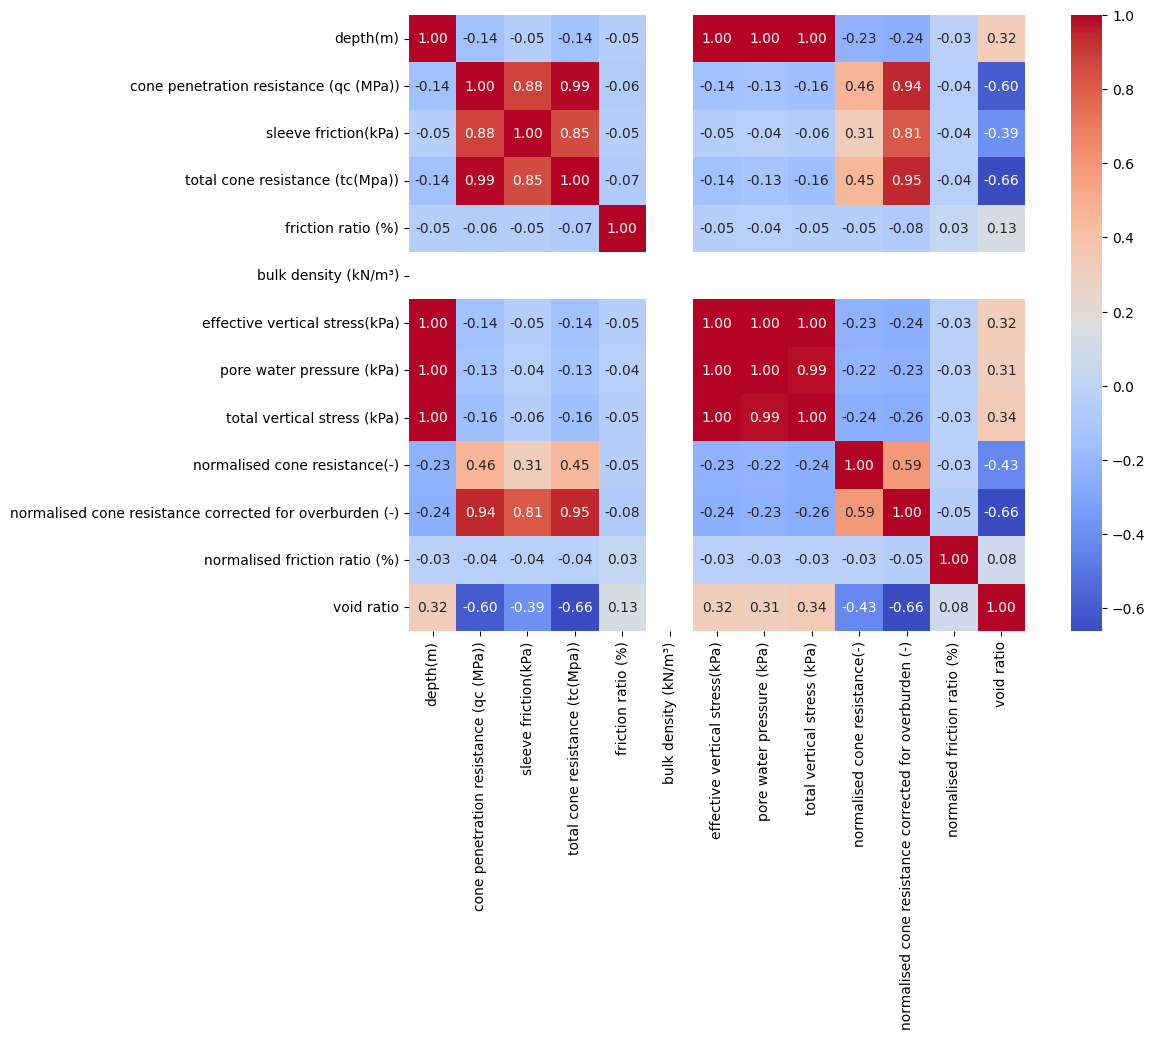

In [47]:
correlation = dataset.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap( correlation, annot=True, fmt=".2f", cmap="coolwarm" , cbar = True , square = True)

for understanding of the data we have taken the heat map and for values greater than 0.8 and less than -0.8 the values are corelated to each other

Training and Testing the data

In [48]:
X = dataset.drop('Soil Class' , axis = 1)
Y = dataset['Soil Class']

le = LabelEncoder()
dataset['Soil Class'] = le.fit_transform(dataset['Soil Class'])

X_train , X_test, Y_train , Y_test = train_test_split(X, Y , test_size = 0.2 , random_state = 42)

In [49]:
model = LGBMClassifier()
model.fit(X_train , Y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000436 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2880
[LightGBM] [Info] Number of data points in the train set: 1920, number of used features: 12
[LightGBM] [Info] Start training from score -1.820288
[LightGBM] [Info] Start training from score -1.810687
[LightGBM] [Info] Start training from score -1.791759
[LightGBM] [Info] Start training from score -1.801179
[LightGBM] [Info] Start training from score -1.767067
[LightGBM] [Info] Start training from score -1.760988
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

LGBMClassifier()

Here it means than my model recognized no relation to some of the coulmns in the data, its saying that some part of the data has no part in predicting the soil type like normalized qc, cy need corrected qc as we have qc we dont really need these.

Model Evaluation

In [50]:
prediction = model.predict(X_test)
print('Accuracy : ' , accuracy_score(Y_test , prediction) )

Accuracy :  0.9791666666666666


In [51]:
dataset['Soil Class'].value_counts()

,count
Soil Class,
0,400
2,400
5,400
3,400
1,400
4,400


In [52]:
print(confusion_matrix(Y_test , prediction))

[[88  1  0  0  0  0]
 [ 3 83  0  0  0  0]
 [ 1  1 78  0  0  0]
 [ 0  0  0 79  4  0]
 [ 0  0  0  0 72  0]
 [ 0  0  0  0  0 70]]


In [54]:
print(classification_report(Y_test, prediction, target_names=le.classes_))

                                      precision    recall  f1-score   support

Class 1: Gravelly sand to dense sand       0.96      0.99      0.97        89
         Class 2: Sand to silty sand       0.98      0.97      0.97        86
   Class 3: Silty sand to sandy silt       1.00      0.97      0.99        80
  Class 4: Clayey silt to silty clay       1.00      0.95      0.98        83
                       Class 5: Clay       0.95      1.00      0.97        72
        Class 6: Organic soil / peat       1.00      1.00      1.00        70

                            accuracy                           0.98       480
                           macro avg       0.98      0.98      0.98       480
                        weighted avg       0.98      0.98      0.98       480

